In [6]:
os.environ["CUDA_VISIBLE_DEVICES"]="0"

NameError: name 'os' is not defined

In [7]:
import os


In [8]:
import torch
import os

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"Device Count: {torch.cuda.device_count()}")
print(f"Current Device: {torch.cuda.current_device() if torch.cuda.is_available() else 'None'}")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', 'Not Set')}")

PyTorch Version: 2.9.0+cu128
CUDA Available: True
CUDA Version: 12.8
Device Count: 1
Current Device: 0
CUDA_VISIBLE_DEVICES: Not Set


In [ ]:
pip install segmentation-models-pytorch

Note: you may need to restart the kernel to use updated packages.


In [9]:
import torch
import segmentation_models_pytorch as smp

/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,  
    in_channels=2,                 
    classes=2                 
)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import rasterio
import numpy as np
from pathlib import Path
import kornia.augmentation as K
import kornia.augmentation.container as C
from typing import List, Optional, Tuple

# Sentinel-1 mean/std (from Satlas-S1)
S1_MEAN = [166.36275909, 88.45542715]
S1_STD = [64.83126309, 43.07350145]


# -----------------------------
# 🔹 Data Augmentation Module
# -----------------------------
class DataAugmentation(nn.Module):
    def __init__(self, mean, std, image_size=224):
        super().__init__()
        self.aug = C.AugmentationSequential(
        #     K.RandomResizedCrop(
        #         size=(image_size, image_size),
        #         scale=(0.8, 1.0),
        #         ratio=(0.9, 1.1),
        #     ),
        #     # Optional flips:
            K.RandomHorizontalFlip(p=0.5),
            K.RandomVerticalFlip(p=0.5),
            data_keys=["input", "mask"],  # ensures same transform
        )
        self.normalize = K.Normalize(mean=mean, std=std)


    @torch.no_grad()
    def forward(self, x, y):
        x, y = self.aug(x, y)
        x = self.normalize(x)
        return x, y


# -----------------------------
# 🔹 Segmentation Dataset
# -----------------------------
class SegmentationDataset(Dataset):
    """
    Dataset for Sentinel-1 segmentation with rasterio loading
    and synchronized Kornia augmentations.
    """
    def __init__(self, root_dir: str,
                 image_size=224, mean=S1_MEAN, std=S1_STD):

        self.root_dir = Path(root_dir)
        self.transform = DataAugmentation(mean, std, image_size)
        
        # --- CHANGED: Find files based on new structure ---
        # Use the 'labels' directory as the source of truth
        self.mask_paths = sorted(list(self.root_dir.glob("labels/*.png")))
        
        # Store the other directories for easy access in __getitem__
        self.vv_dir = self.root_dir / "vv"
        self.vh_dir = self.root_dir / "vh"
        
        if not self.mask_paths:
            raise FileNotFoundError(
                f"No masks found in {self.root_dir / 'labels'}. "
                f"Please check your root_dir."
            )

    def __len__(self):
        return len(self.mask_paths)

    def __getitem__(self, idx):
        # ---- Load VV & VH ----
        mask_path = self.mask_paths[idx]
        filename = mask_path.name
        vv_path = self.vv_dir / filename
        vh_path = self.vh_dir / filename
        if not vv_path.exists():
            raise FileNotFoundError(f"Missing corresponding VV file: {vv_path}")
        if not vh_path.exists():
            raise FileNotFoundError(f"Missing corresponding VH file: {vh_path}")
        with rasterio.open(vv_path) as f_vv:
            vv = f_vv.read().astype('float32')  # [1, H, W]
        with rasterio.open(vh_path) as f_vh:
            vh = f_vh.read().astype('float32')  # [1, H, W]

        # ---- Stack into 2-channel Sentinel-1 tensor ----
        s1_img = np.concatenate((vv, vh), axis=0)  # [2, H, W]
        s1_img = torch.from_numpy(s1_img).unsqueeze(0)  # [1, 2, H, W]

        # ---- Load label ----
        with rasterio.open(mask_path) as f_mask:
            label = f_mask.read().astype('float32')  # [1, H, W]

        label = label/255.0
        label = torch.from_numpy(label).unsqueeze(0)  # [1, 1, H, W]
        # ---- Apply augmentation and normalization ----
        s1_img, label = self.transform(s1_img, label)

        label = (label > 0.5).long()  # 0/1 binary

        return {
            "image": s1_img.squeeze(0),  # [2, H, W]
            "mask": label.squeeze(),    # [1, H, W]
        }


# -----------------------------
# 🔹 Dataset Creation Helper
# -----------------------------
def create_train_dataset(
    train_root_dir: str,
    image_size: int = 224,
    mean: Optional[List[float]] = S1_MEAN,
    std: Optional[List[float]] = S1_STD,
) -> 'SegmentationDataset':
    """
    Helper function to create ONLY the training dataset.
    """
    train_dataset = SegmentationDataset(
        root_dir=train_root_dir, # <-- CHANGED
        image_size=image_size,
        mean=mean,
        std=std,
    )

    return train_dataset

/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/kornia/feature/lightglue.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [12]:
import os
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import pandas as pd


class SegmentationTrainer:
    def __init__(
        self,
        model: nn.Module,
        train_loader,
        device: str = 'cuda',
        lr: float = 3e-4,
        num_epochs: int = 100,
        checkpoint_dir: str = 'checkpoints_afterMMU',
        resume_from: str = None  # <--- ADD THIS
    ):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.device = device
        self.num_epochs = num_epochs
        self.checkpoint_dir = checkpoint_dir
        
        # --- THESE ARE NOW THE DEFAULTS ---
        self.optimizer = AdamW(self.model.parameters(), lr=lr, weight_decay=0.01)
        self.scheduler = CosineAnnealingLR(self.optimizer, T_max=num_epochs)
        self.history = []
        self.criterion = nn.CrossEntropyLoss()
        self.best_train_iou = 0.0
        self.start_epoch = 0  # <--- ADD THIS
        
        os.makedirs(checkpoint_dir, exist_ok=True)

        # --- THIS IS THE MAGIC BLOCK ---
        if resume_from:
            print(f"Resuming training from: {resume_from}")
            checkpoint = torch.load(resume_from, map_location=self.device, weights_only=False)
            
            self.model.load_state_dict(checkpoint['model_state_dict'])
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            self.start_epoch = checkpoint['epoch'] + 1 # Start at the *next* epoch
            self.best_train_iou = checkpoint['metrics'].get('iou', 0.0) # Recover best IoU
    
    def train_epoch(self, epoch: int) -> dict:
        """Train for one epoch"""
        self.model.train()
        total_loss, total_iou = 0.0, 0.0
        
        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch+1}/{self.num_epochs} [Train]')
        for batch in pbar:
            images = batch['image'].to(self.device)
            masks = batch['mask'].long().to(self.device, non_blocking=True)
            logits = self.model(images)           
            # Compute loss
            loss = self.criterion(logits, masks)           
            # Backward and optimize
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            # Metrics
            iou = self.compute_iou(logits, masks)
            total_loss += loss.item()
            total_iou += iou
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'IoU': f'{iou:.4f}'})
        
        avg_loss = total_loss / len(self.train_loader)
        avg_iou = total_iou / len(self.train_loader)
        return {'loss': avg_loss, 'iou': avg_iou}
    

    def compute_iou(self, logits: torch.Tensor, masks: torch.Tensor) -> float:
        """Compute mean IoU"""
        preds = torch.argmax(logits, dim=1)
        num_classes = logits.shape[1]
        
        iou_per_class = []
        for cls in range(num_classes):
            pred_cls = (preds == cls)
            mask_cls = (masks == cls)
            intersection = (pred_cls & mask_cls).sum().float()
            union = (pred_cls | mask_cls).sum().float()
            if union > 0:
                iou_per_class.append((intersection / union).item())
        
        return np.mean(iou_per_class) if iou_per_class else 0.0
    
    def save_checkpoint(self, epoch: int, metrics: dict, is_best: bool = False):
        """Save model checkpoint"""
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'metrics': metrics,
        }
        
        path = os.path.join(self.checkpoint_dir, f'checkpoint_epoch_afterMMU_{epoch}.pth')
        torch.save(checkpoint, path)
        
        if is_best:
            best_path = os.path.join(self.checkpoint_dir, 'best_model.pth')
            torch.save(checkpoint, best_path)
    
    def train(self):
        """Full training loop"""
        for epoch in range(self.start_epoch, self.num_epochs):
            train_metrics = self.train_epoch(epoch)
            self.scheduler.step()
            
            print(f"\nEpoch {epoch+1}/{self.num_epochs}")
            print(f"Train - Loss: {train_metrics['loss']:.4f}, IoU: {train_metrics['iou']:.4f}")
            self.history.append({
                    'epoch': epoch + 1,
                    'loss': train_metrics['loss'],
                    'iou': train_metrics['iou']
                })
            
            # Save checkpoint
            is_best = train_metrics['iou'] > self.best_train_iou
            if is_best:
                self.best_train_iou = train_metrics['iou']
            
            if (epoch + 1) % 5 == 0 or is_best:
                self.save_checkpoint(epoch, train_metrics, is_best)

        print(f"\n✅ Training completed! Best Train IoU: {self.best_train_iou:.4f}")
        pd.DataFrame(self.history).to_csv(
            os.path.join(self.checkpoint_dir, 'training_history.csv'), index=False
        )



In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
from tqdm import tqdm
from typing import List, Tuple, Optional
import os
from PIL import Image
import rasterio

In [14]:
import torch


# ============================================================================
# Main Training Script
# ============================================================================

def main():
    """Example usage of the training pipeline"""
    
    # Configuration
    config = {
        "num_classes": 2,
        "batch_size": 200,
        "lr": 3e-4,
        "num_epochs": 100,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
    }
    
    
    
    train_dir='/home/arm/Documents/ARM/tiled_dataset'

    train_dataset = create_train_dataset(train_dir)
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, num_workers=10, pin_memory=True,  prefetch_factor=4,  persistent_workers=True)


    model=smp.DeepLabV3Plus(
        encoder_name="resnet50",
        encoder_weights=None,  
        in_channels=2,                 
        classes=config['num_classes']                 
    )


    trainer = SegmentationTrainer(
        model=model,
        train_loader=train_loader,
        device=config['device'],
        lr=config['lr'],
        num_epochs=config['num_epochs']
    )
    print(config['device'])
    # Start training
    trainer.train()
    
    
    print("Training complete!")


if __name__ == "__main__":
    main()

cuda


Epoch 1/100 [Train]:   0%|          | 0/737 [00:00<?, ?it/s]/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset 


Epoch 1/100
Train - Loss: 0.1175, IoU: 0.9066


Epoch 2/100 [Train]: 100%|██████████| 737/737 [04:06<00:00,  2.99it/s, loss=0.0992, IoU=0.9207]



Epoch 2/100
Train - Loss: 0.0912, IoU: 0.9260


...


Epoch 98/100
Train - Loss: 0.0194, IoU: 0.9831


Epoch 99/100 [Train]: 100%|██████████| 737/737 [03:57<00:00,  3.10it/s, loss=0.0196, IoU=0.9826]



Epoch 99/100
Train - Loss: 0.0194, IoU: 0.9830


Epoch 100/100 [Train]: 100%|██████████| 737/737 [03:58<00:00,  3.09it/s, loss=0.0195, IoU=0.9826]



Epoch 100/100
Train - Loss: 0.0194, IoU: 0.9830

✅ Training completed! Best Train IoU: 0.9831
Training complete!


In [10]:
config['device']

UsageError: Invalid config statement: "['device']", should be `Class.trait = value`.


In [15]:
import torch
torch.cuda.empty_cache()

In [19]:
del model

SENTINEL-1 SEGMENTATION INFERENCE
✅ Loaded checkpoint from epoch 1
   Best IoU: 0.8076

📂 Loading 10 random VV/VH pairs
Found 9504 matching VV/VH pairs

🚀 Running inference...

📊 Generating visualizations...


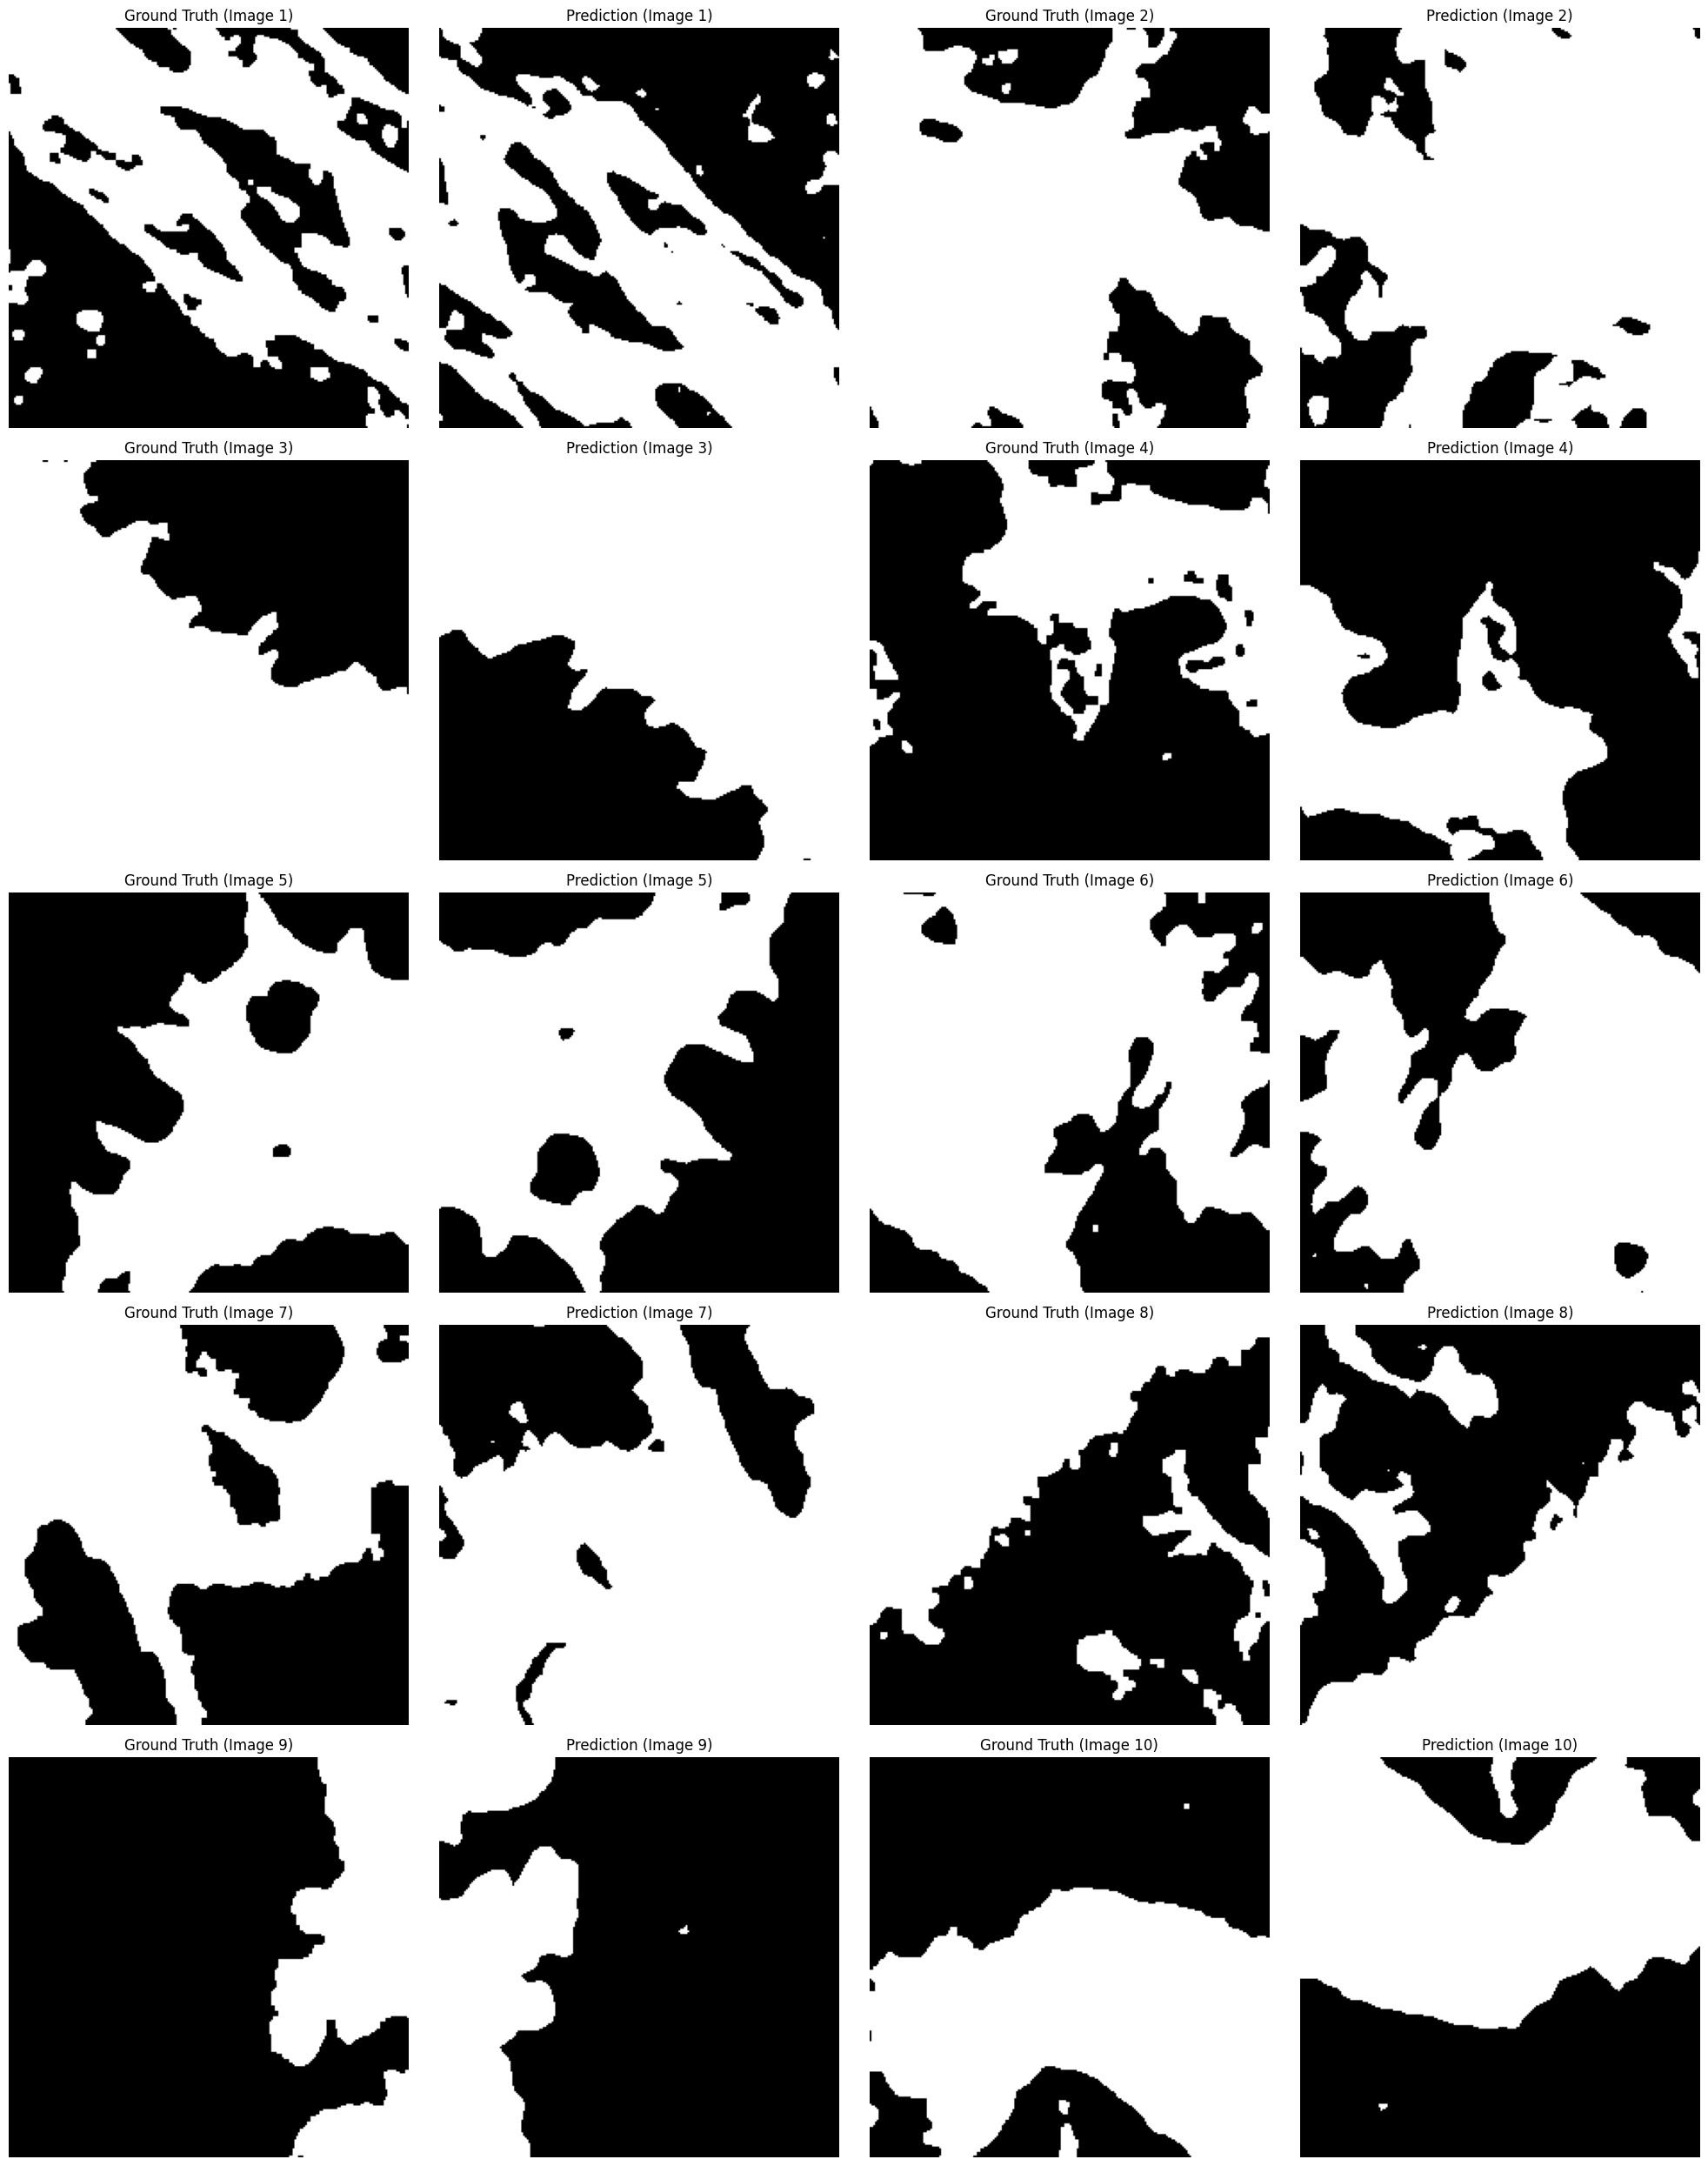

✅ Saved grid to: inference_results/inference_grid.png

PREDICTION STATISTICS

Image 1: FID343_Q1_2021_S1_280925_tile_x0_y0.png
  Classes: [0 1]
  Pixels: [23011 27165]
  Percentage: ['45.86%', '54.14%']

Image 2: FID163_Q1_2022_S1_240925_tile_x672_y224.png
  Classes: [0 1]
  Pixels: [ 9142 41034]
  Percentage: ['18.22%', '81.78%']

Image 3: FID48_Q3_2023_S1_Reservoir_Batch_01_170925_tile_x224_y0.png
  Classes: [0 1]
  Pixels: [16402 33774]
  Percentage: ['32.69%', '67.31%']

Image 4: FID296_Q4_2017_S1_280925_tile_x672_y224.png
  Classes: [0 1]
  Pixels: [35337 14839]
  Percentage: ['70.43%', '29.57%']

Image 5: FID53_Q4_2019_S1_Reservoir_Batch_02_190925_tile_x0_y0.png
  Classes: [0 1]
  Pixels: [24393 25783]
  Percentage: ['48.61%', '51.39%']

Image 6: FID337_Q3_2020_S1_280925_tile_x1120_y896.png
  Classes: [0 1]
  Pixels: [13228 36948]
  Percentage: ['26.36%', '73.64%']

Image 7: FID2_Q1_2022_S1_Reservoir_Batch_01_170925_tile_x224_y224.png
  Classes: [0 1]
  Pixels: [12413 37763]
  Pe

In [12]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import rasterio
import random
from pathlib import Path

# Assumes extract_patch_features and SegmentationDataset are already defined in your notebook
# If not, import them:
# from your_training_file import extract_patch_features
# from your_dataset_file import SegmentationDataset

# ============================================================================
# CONFIGURATION
# ============================================================================

CHECKPOINT_PATH = '/home/arm/Desktop/ARM/Codes/checkpoints/checkpoint_epoch_batchsize100_1.pth'
root_dir='/home/arm/Documents/ARM/tiled_dataset'
VV_DIR='/home/arm/Documents/ARM/tiled_dataset/vv'
VH_DIR='/home/arm/Documents/ARM/tiled_dataset/vh'
labels_dir='/home/arm/Documents/ARM/tiled_dataset/labels'
NUM_IMAGES = 10
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Sentinel-1 constants
S1_MEAN = [166.36275909, 88.45542715]
S1_STD = [64.83126309, 43.07350145]
WAVELENGTHS = [3.75, 3.75]

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def load_checkpoint(checkpoint_path, model, device='cuda'):
    """Load trained decoder weights from checkpoint"""
    checkpoint = torch.load(checkpoint_path, map_location=device,weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model=model.to(device)
    model.eval()
    
    print(f"✅ Loaded checkpoint from epoch {checkpoint['epoch']}")
    print(f"   Best IoU: {checkpoint['metrics']['iou']:.4f}")
    
    return model


def get_random_image_pairs(vv_dir, vh_dir, labels_dir, num_images=10):
    """Get random matching VV and VH image pairs by FID"""
    vv_dir = Path(vv_dir)
    vh_dir = Path(vh_dir)
    labels_dir = Path(labels_dir)
    
    def extract_fid(filename):
        stem = Path(filename).stem
        parts = stem.split('_')
        if len(parts) >= 3:
            return '_'.join(parts[:3])
        return stem
    
    # Collect VV files
    vv_files = {}
    for f in vv_dir.glob('*'):
        if f.is_file() and f.suffix.lower() in ['.png', '.tif', '.tiff']:
            fid = extract_fid(f.name)
            vv_files[fid] = f
    
    # Collect VH files
    vh_files = {}
    for f in vh_dir.glob('*'):
        if f.is_file() and f.suffix.lower() in ['.png', '.tif', '.tiff']:
            fid = extract_fid(f.name)
            vh_files[fid] = f
    labels_files = {}
    for f in labels_dir.glob('*'):
        if f.is_file() and f.suffix.lower() in ['.png', '.tif', '.tiff']:
            fid = extract_fid(f.name)
            labels_files[fid] = f
    
    # Find common FIDs
    common_fids = set(vv_files.keys()) & set(vh_files.keys())
    
    if len(common_fids) == 0:
        raise ValueError("No matching VV/VH pairs found!")
    
    print(f"Found {len(common_fids)} matching VV/VH pairs")
    
    # Sample random pairs
    num_to_sample = min(num_images, len(common_fids))
    sampled_fids = list(common_fids)[:10]
    
    vv_paths = [str(vv_files[fid]) for fid in sampled_fids]
    vh_paths = [str(vh_files[fid]) for fid in sampled_fids]
    labels_paths = [str(labels_files[fid]) for fid in sampled_fids]

    
    return vv_paths, vh_paths, labels_paths


def run_inference(model, vv_paths, vh_paths, labels_paths, device='cuda'):
    """Run inference on Sentinel-1 image pairs using dataset preprocessing"""
    from pathlib import Path
    import tempfile
    import shutil
    
    model.eval()
    
    results = []
    
    # Create temporary directories for dataset loader
    temp_dir = tempfile.mkdtemp()
    temp_vv = os.path.join(temp_dir, 'vv')
    temp_vh = os.path.join(temp_dir, 'vh')
    temp_labels = os.path.join(temp_dir, 'labels')  # ✅ Changed
    os.makedirs(temp_vv, exist_ok=True)
    os.makedirs(temp_vh, exist_ok=True)
    os.makedirs(temp_labels, exist_ok=True)  # ✅ Changed
    
    try:
        # Copy files to temp with matching FIDs
        for idx, (vv_path, vh_path,labels_path) in enumerate(zip(vv_paths, vh_paths,labels_paths)):
            # Use .png extension to match dataset glob pattern
            base_name = f'FID{idx}_Q1_2015.png'  # ✅ Consistent .png
            
            shutil.copy(vv_path, os.path.join(temp_vv, base_name))
            shutil.copy(vh_path, os.path.join(temp_vh, base_name))
            shutil.copy(vh_path, os.path.join(temp_labels, base_name))

            
            
        
        # ✅ Create dataset with temp_dir
        dataset = SegmentationDataset(
            root_dir=temp_dir,  # ✅ Fixed!
            image_size=224,
            mean=S1_MEAN,
            std=S1_STD
        )
        
        # Run inference
        with torch.no_grad():
            for idx, sample in enumerate(dataset):
                image = sample['image'].unsqueeze(0).to(device)  # [1, 2, H, W]
                logits = model(image)
                
                # Get predictions
                pred_mask = torch.argmax(logits, dim=1).cpu().numpy()[0]
                probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
                
                results.append({
                    'vv_path': vv_paths[idx],
                    'vh_path': vh_paths[idx],
                    'labels_path': labels_paths[idx],
                    'prediction': pred_mask,
                    'probabilities': probs
                })
    
    finally:
        # Cleanup temp directory
        shutil.rmtree(temp_dir)
    
    return results


import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio

def visualize_results(results, save_dir='inference_results'):
    """
    Visualize predictions in a 5x4 grid (2 sets per row).
    """
    os.makedirs(save_dir, exist_ok=True)
    
    num_results = len(results)
    if num_results == 0:
        print("No results to visualize.")
        return

    # 👈 --- CHANGED ---
    # We need 2 sets per row, so 4 columns (GT, Pred, GT, Pred)
    # We need 5 rows to fit 10 sets
    num_rows = (num_results + 1) // 2  # This calculates 5 rows for 10 results
    num_cols = 4 
    
    # Create one big figure
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))

    # Handle edge case: if num_rows=1, axes is 1D. Make it 2D.
    if num_rows == 1:
        axes = np.array([axes])

    for idx, result in enumerate(results):
        with rasterio.open(result['labels_path']) as f:
            label = f.read(1)

        # Normalize label to binary [0, 1]
        label_binary = (label > 0).astype('uint8')
        pred_mask = result['prediction']

        # 👈 --- NEW MAPPING LOGIC ---
        # Calculate the grid position
        row = idx // 2
        col_start = (idx % 2) * 2  # 0 if even (left pair), 2 if odd (right pair)

        # --- 1. Ground Truth Label ---
        ax_gt = axes[row, col_start]
        ax_gt.imshow(label_binary, cmap='gray', vmin=0, vmax=1)
        ax_gt.set_title(f'Ground Truth (Image {idx+1})')
        ax_gt.axis('off')

        # --- 2. Predicted Mask ---
        ax_pred = axes[row, col_start + 1]
        ax_pred.imshow(pred_mask, cmap='gray', vmin=0, vmax=1)
        ax_pred.set_title(f'Prediction (Image {idx+1})')
        ax_pred.axis('off')

    # 👈 --- Hide any unused subplots ---
    # If we have an odd number of results (e.g., 9), hide the last 2 plots
    if num_results % 2 == 1:
        axes[-1, -1].axis('off') # Hide last prediction spot
        axes[-1, -2].axis('off') # Hide last ground truth spot

    # ----------------------------------------------------
    # 👇 --- SAVING IS OUTSIDE THE LOOP ---
    # ----------------------------------------------------
    
    plt.tight_layout()
    save_path = os.path.join(save_dir, 'inference_grid.png') 
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"✅ Saved grid to: {save_path}")



def print_statistics(results):
    """Print prediction statistics"""
    print("\n" + "=" * 60)
    print("PREDICTION STATISTICS")
    print("=" * 60)
    for idx, result in enumerate(results):
        pred = result['prediction']
        unique_classes, counts = np.unique(pred, return_counts=True)
        percentages = (counts / pred.size) * 100
        
        vv_name = Path(result['vv_path']).name
        print(f"\nImage {idx+1}: {vv_name}")
        print(f"  Classes: {unique_classes}")
        print(f"  Pixels: {counts}")
        print(f"  Percentage: {[f'{p:.2f}%' for p in percentages]}")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("=" * 60)
print("SENTINEL-1 SEGMENTATION INFERENCE")
print("=" * 60)


model=smp.DeepLabV3Plus(
        encoder_name="resnet50",
        encoder_weights=None,  
        in_channels=2,                 
        classes=2
)
# Load checkpoint
model= load_checkpoint(CHECKPOINT_PATH, model, DEVICE)

# Get random image pairs
print(f"\n📂 Loading {NUM_IMAGES} random VV/VH pairs")
vv_paths, vh_paths, labels_paths = get_random_image_pairs(VV_DIR, VH_DIR, labels_dir, NUM_IMAGES)

# Run inference
print("\n🚀 Running inference...")
results = run_inference(model, vv_paths, vh_paths, labels_paths, DEVICE)

# Visualize
print("\n📊 Generating visualizations...")
visualize_results(results)

# Print statistics
print_statistics(results)

print(f"\n✅ Done! Uncomment the code after initializing your models.")

SENTINEL-1 LARGE IMAGE (STITCHED) INFERENCE
✅ Loaded checkpoint from epoch 98
Found 12081 total large images.
Randomly selected 10 images to process.
Found 10 large images to predict.


Predicting large images:   0%|          | 0/10 [00:00<?, ?it/s]/home/arm/Desktop/ARM/Codes/armvenv/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
Predicting large images: 100%|██████████| 10/10 [00:01<00:00,  7.00it/s]



📊 Generating visualizations...


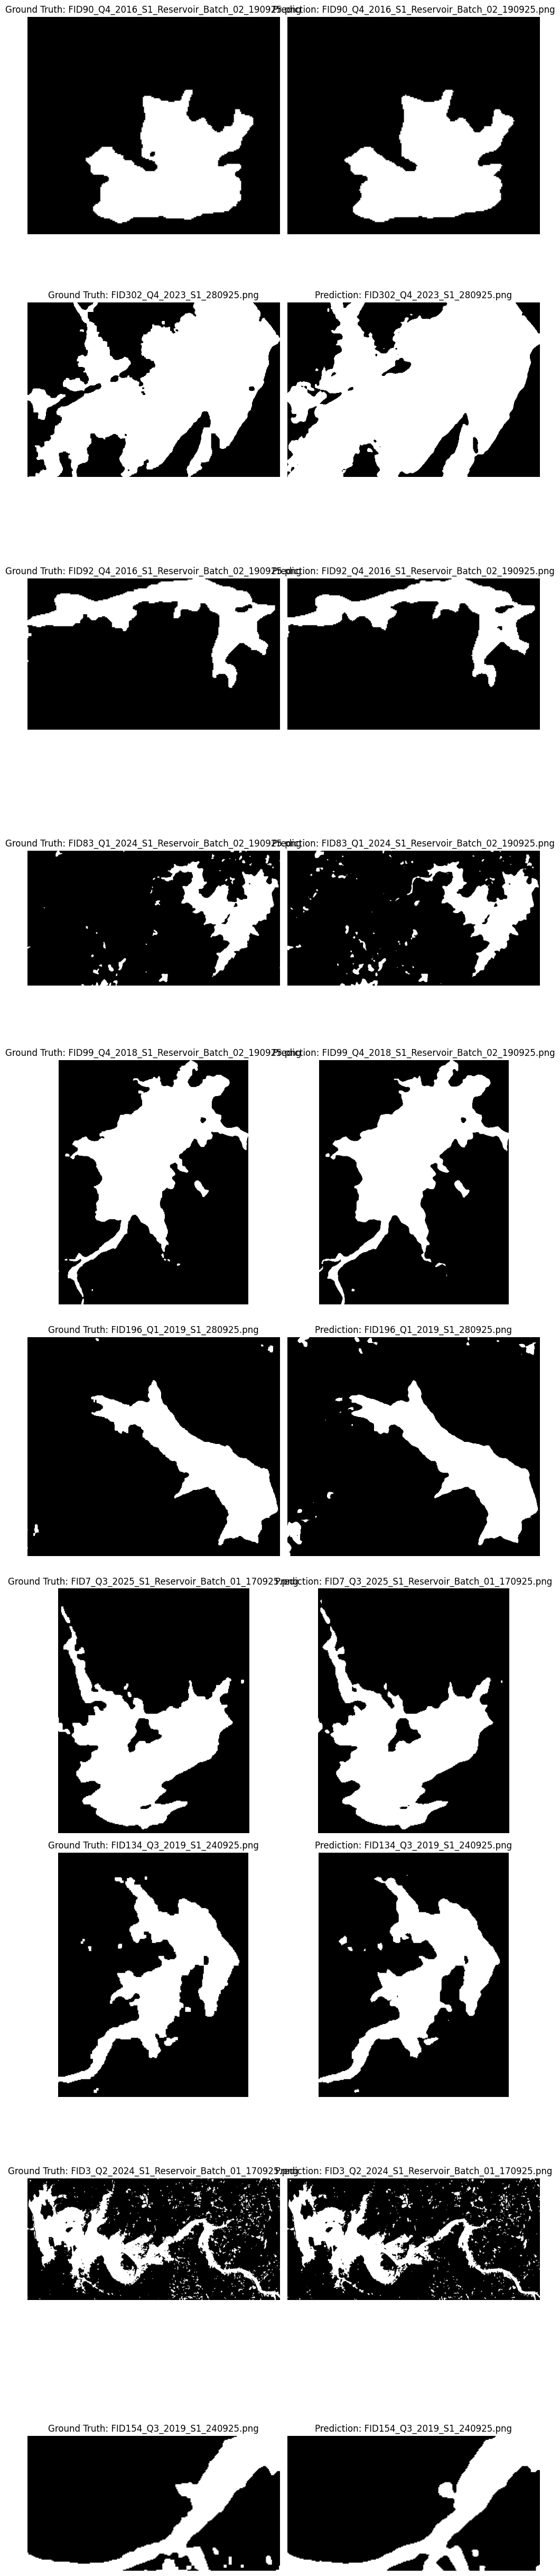

✅ Saved stitched comparison grid to: inference_results_large/stitched_inference_comparison.png

✅ Done!


In [14]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path
from tqdm import tqdm
import random
# (Import your model and SegmentationDataset definitions here if they are in another file)
# from your_model_file import smp, SegmentationDataset
# (Assuming smp and SegmentationDataset are defined or imported)
import segmentation_models_pytorch as smp 

# ============================================================================
# CONFIGURATION
# ============================================================================

# --- 1. Point to your TRAINED MODEL
CHECKPOINT_PATH = '/home/arm/Desktop/ARM/Codes/checkpoints/best_model.pth'

# --- 2. Point to your NEW, LARGE images (NOT the 'tiled_dataset' folder)
# These are the original, full-size images
LARGE_IMAGE_VV_DIR = Path('/home/arm/Documents/ARM/8bit png files/vv')
LARGE_IMAGE_VH_DIR = Path('/home/arm/Documents/ARM/8bit png files/vh')
LARGE_IMAGE_LABELS_DIR = Path('/home/arm/Documents/ARM/8bit png files/labels')

# --- 3. Output directory for visualization
SAVE_DIR = 'inference_results_large'

# --- 4. Model & Inference parameters
TILE_SIZE = 224
STRIDE = 112  # 50% overlap. This is the key to smoothing.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_CLASSES = 2
SEED = 103
NUM_IMAGES_TO_TEST = 10

# --- 5. Normalization constants (Must be 100% identical to training!)
# (VV_mean, VH_mean)
S1_MEAN = torch.tensor([166.36275909, 88.45542715], dtype=torch.float32).to(DEVICE)
# (VV_std, VH_std)
S1_STD = torch.tensor([64.83126309, 43.07350145], dtype=torch.float32).to(DEVICE)

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def load_checkpoint(checkpoint_path, model, device='cuda'):
    """Load trained decoder weights from checkpoint"""
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Handle checkpoints saved with DataParallel
    state_dict = checkpoint['model_state_dict']
    if list(state_dict.keys())[0].startswith('module.'):
        state_dict = {k[7:]: v for k, v in state_dict.items()}
        
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    
    print(f"✅ Loaded checkpoint from epoch {checkpoint['epoch']}")
    return model

def normalize_tensor(tensor):
    """Normalize a [2, H, W] tensor using the global mean/std"""
    # tensor.shape[0] must be 2
    mean = S1_MEAN.view(2, 1, 1)
    std = S1_STD.view(2, 1, 1)
    return (tensor - mean) / std

def predict_large_image(model, vv_path, vh_path, tile_size, stride, device):
    """
    Run sliding-window inference with overlapping tiles on a large image.
    """
    model.eval()

    # 1. Load large images
    with rasterio.open(vv_path) as f_vv:
        vv = f_vv.read(1).astype('float32') # [H, W]
        H_orig, W_orig = vv.shape
    with rasterio.open(vh_path) as f_vh:
        vh = f_vh.read(1).astype('float32') # [H, W]

    # 2. Preprocess: Stack, convert to tensor, normalize
    # (VV, VH) order must match your training!
    image = np.stack([vv, vh], axis=0) # [2, H, W]
    image_tensor = torch.from_numpy(image).to(device)
    image_tensor = normalize_tensor(image_tensor) # [2, H, W]

    # 3. Pad the image
    # We pad the image so that the tiles (with stride) fit perfectly
    # Calculate padding for (right, bottom)
    pad_w = (stride - (W_orig - tile_size) % stride) % stride
    pad_h = (stride - (H_orig - tile_size) % stride) % stride
    
    # Pad tuple is (left, right, top, bottom)
    image_tensor = F.pad(image_tensor, (0, pad_w, 0, pad_h), mode='reflect')
    
    C, H_padded, W_padded = image_tensor.shape
    
    # 4. Prepare output tensors
    # We store sums of probabilities (logits)
    prediction_sum = torch.zeros((NUM_CLASSES, H_padded, W_padded), dtype=torch.float32).to(device)
    # We count how many times each pixel was predicted
    pixel_counts = torch.zeros((1, H_padded, W_padded), dtype=torch.float32).to(device)

    # 5. The Sliding Window
    with torch.no_grad():
        for y in range(0, H_padded - tile_size + 1, stride):
            for x in range(0, W_padded - tile_size + 1, stride):
                
                # Extract tile
                tile = image_tensor[:, y:y+tile_size, x:x+tile_size].unsqueeze(0) # [1, 2, T, T]
                
                # Run inference
                logits = model(tile) # [1, 2, T, T]
                
                # We add the *probabilities* (softmax) for better blending
                probs = torch.softmax(logits, dim=1)
                
                # Add to our sum tensors
                prediction_sum[:, y:y+tile_size, x:x+tile_size] += probs.squeeze(0)
                pixel_counts[:, y:y+tile_size, x:x+tile_size] += 1

    # 6. Average the predictions
    # Add a small epsilon to avoid division by zero (though pixel_counts should be >= 1)
    avg_probs = prediction_sum / (pixel_counts + 1e-6)
    
    # 7. Get final class predictions
    final_prediction_padded = torch.argmax(avg_probs, dim=0)
    
    # 8. Un-pad to original size
    final_prediction = final_prediction_padded[0:H_orig, 0:W_orig]
    
    return final_prediction.cpu().numpy()


def visualize_stitched_results(results_list, save_dir):
    """
    Visualize ground truth vs. stitched prediction.
    """
    os.makedirs(save_dir, exist_ok=True)
    
    num_images = len(results_list)
    if num_images == 0:
        print("No results to visualize.")
        return

    # Create a N x 2 grid: (GT, Pred), (GT, Pred), ...
    fig, axes = plt.subplots(num_images, 2, figsize=(10, 5 * num_images))
    
    # Handle edge case: if num_images=1, axes is 1D. Make it 2D.
    if num_images == 1:
        axes = np.array([axes])

    for idx, result in enumerate(results_list):
        # 1. Ground Truth
        ax_gt = axes[idx, 0]
        ax_gt.imshow(result['ground_truth'], cmap='gray', vmin=0, vmax=1)
        ax_gt.set_title(f"Ground Truth: {result['name']}")
        ax_gt.axis('off')

        # 2. Prediction
        ax_pred = axes[idx, 1]
        ax_pred.imshow(result['prediction'], cmap='gray', vmin=0, vmax=1)
        ax_pred.set_title(f"Prediction: {result['name']}")
        ax_pred.axis('off')

    plt.tight_layout()
    save_path = os.path.join(save_dir, 'stitched_inference_comparison.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"✅ Saved stitched comparison grid to: {save_path}")

# ============================================================================
# NEW MAIN EXECUTION
# ============================================================================

print("=" * 60)
print("SENTINEL-1 LARGE IMAGE (STITCHED) INFERENCE")
print("=" * 60)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 1. Initialize Model
# (This assumes you are using the DeepLabV3+ from your example)
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=2,
    classes=NUM_CLASSES
)

# 2. Load trained weights
model = load_checkpoint(CHECKPOINT_PATH, model, DEVICE)

# 3. Find large images to predict
# We use the VV directory as the "master list"
all_vv_paths = sorted(list(LARGE_IMAGE_VV_DIR.glob('*.png'))) # Or .tif
if not all_vv_paths:
    print(f"Error: No images found in {LARGE_IMAGE_VV_DIR}")
    
print(f"Found {len(all_vv_paths)} total large images.")

# --- 4. Sample the files ---
if len(all_vv_paths) > NUM_IMAGES_TO_TEST:
    vv_paths_to_run = random.sample(all_vv_paths, NUM_IMAGES_TO_TEST)
    print(f"Randomly selected {NUM_IMAGES_TO_TEST} images to process.")
else:
    vv_paths_to_run = all_vv_paths
    print(f"Processing all {len(all_vv_paths)} images (less than {NUM_IMAGES_TO_TEST}).")

results_list = []


print(f"Found {len(vv_paths_to_run)} large images to predict.")

results_list = []

# 4. Loop, Predict, and Collect
# Use tqdm for a progress bar
for vv_path in tqdm(vv_paths_to_run, desc="Predicting large images"):
    basename = vv_path.name
    
    # --- IMPORTANT: Adjust your label matching pattern ---
    # This assumes your label has a suffix like '_ensemble_cleaned.png'
    # Change this if your pattern is different!
    label_match = list(LARGE_IMAGE_LABELS_DIR.glob(f"{vv_path.stem}*.png"))
    vh_path = LARGE_IMAGE_VH_DIR / basename
    
    if not vh_path.exists():
        print(f"Warning: Skipping {basename}, missing VH file.")
        continue
    if not label_match:
        print(f"Warning: Skipping {basename}, missing Label file.")
        continue
        
    label_path = label_match[0] # Use the first match

    # --- This is the new core logic ---
    prediction_mask = predict_large_image(
        model=model,
        vv_path=vv_path,
        vh_path=vh_path,
        tile_size=TILE_SIZE,
        stride=STRIDE,
        device=DEVICE
    )
    # -----------------------------------

    # Load the ground truth for comparison
    with rasterio.open(label_path) as f:
        ground_truth = (f.read(1) > 127).astype('uint8') # Binarize

    results_list.append({
        'prediction': prediction_mask,
        'ground_truth': ground_truth,
        'name': basename
    })

# 6. Visualize the results
if results_list:
    print("\n📊 Generating visualizations...")
    visualize_stitched_results(results_list, SAVE_DIR)
else:
    print("No results were generated.")

print(f"\n✅ Done!")